# 🌍 Hackathon IndabaX Cameroon 2026
## Étape 2 — Feature Engineering & Modélisation
> **Cible :** `iqa_global` | **Split :** 80/20 | **Tâche :** Régression

---
## 📦 0. Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LinearRegression, Ridge
from sklearn.ensemble        import RandomForestRegressor
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline        import Pipeline


import statsmodels.api as sm


from xgboost  import XGBRegressor
from lightgbm import LGBMRegressor

import joblib

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
TARGET       = 'iqa_global'
print('✅ Imports OK')

✅ Imports OK


---
## 📂 1. Chargement du dataset

In [6]:
DATA_PATH = 'data/meteo.csv'

df = pd.read_csv(DATA_PATH)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(['city', 'time']).reset_index(drop=True)

print(f'✅ Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'   Période : {df["time"].min().date()} → {df["time"].max().date()}')
print(f'   Villes  : {df["city"].nunique()} | Régions : {df["region"].nunique()}')

✅ Dataset chargé : 87,240 lignes × 56 colonnes
   Période : 2020-01-01 → 2025-12-20
   Villes  : 40 | Régions : 10


---
## 🔧 2. Feature Engineering

### 2.1 — Encodage des variables catégorielles

In [7]:
df_feat = df.copy()


# Encodage Label des colonnes catégorielles
le_city   = LabelEncoder()
le_region = LabelEncoder()
le_saison = LabelEncoder()

df_feat['city_enc']   = le_city.fit_transform(df_feat['city'])
df_feat['region_enc'] = le_region.fit_transform(df_feat['region'])
df_feat['saison_enc'] = le_saison.fit_transform(df_feat['saison'])

print('Mapping saisons :', dict(zip(le_saison.classes_, le_saison.transform(le_saison.classes_))))
print('✅ Encodage effectué')

Mapping saisons : {'Harmattan': np.int64(0), 'Saison_pluies': np.int64(1), 'Transition': np.int64(2)}
✅ Encodage effectué


### 2.2 — Features cycliques (jour de l'année, semaine)

In [8]:
# Transformation sinus/cosinus pour capturer la cyclicité
df_feat['doy_sin'] = np.sin(2 * np.pi * df_feat['day_of_year']  / 365)
df_feat['doy_cos'] = np.cos(2 * np.pi * df_feat['day_of_year']  / 365)
df_feat['woy_sin'] = np.sin(2 * np.pi * df_feat['week_of_year'] / 52)
df_feat['woy_cos'] = np.cos(2 * np.pi * df_feat['week_of_year'] / 52)

print('✅ Features cycliques ajoutées : doy_sin, doy_cos, woy_sin, woy_cos')

✅ Features cycliques ajoutées : doy_sin, doy_cos, woy_sin, woy_cos


### 2.3 — Lag features et rolling means (par ville)

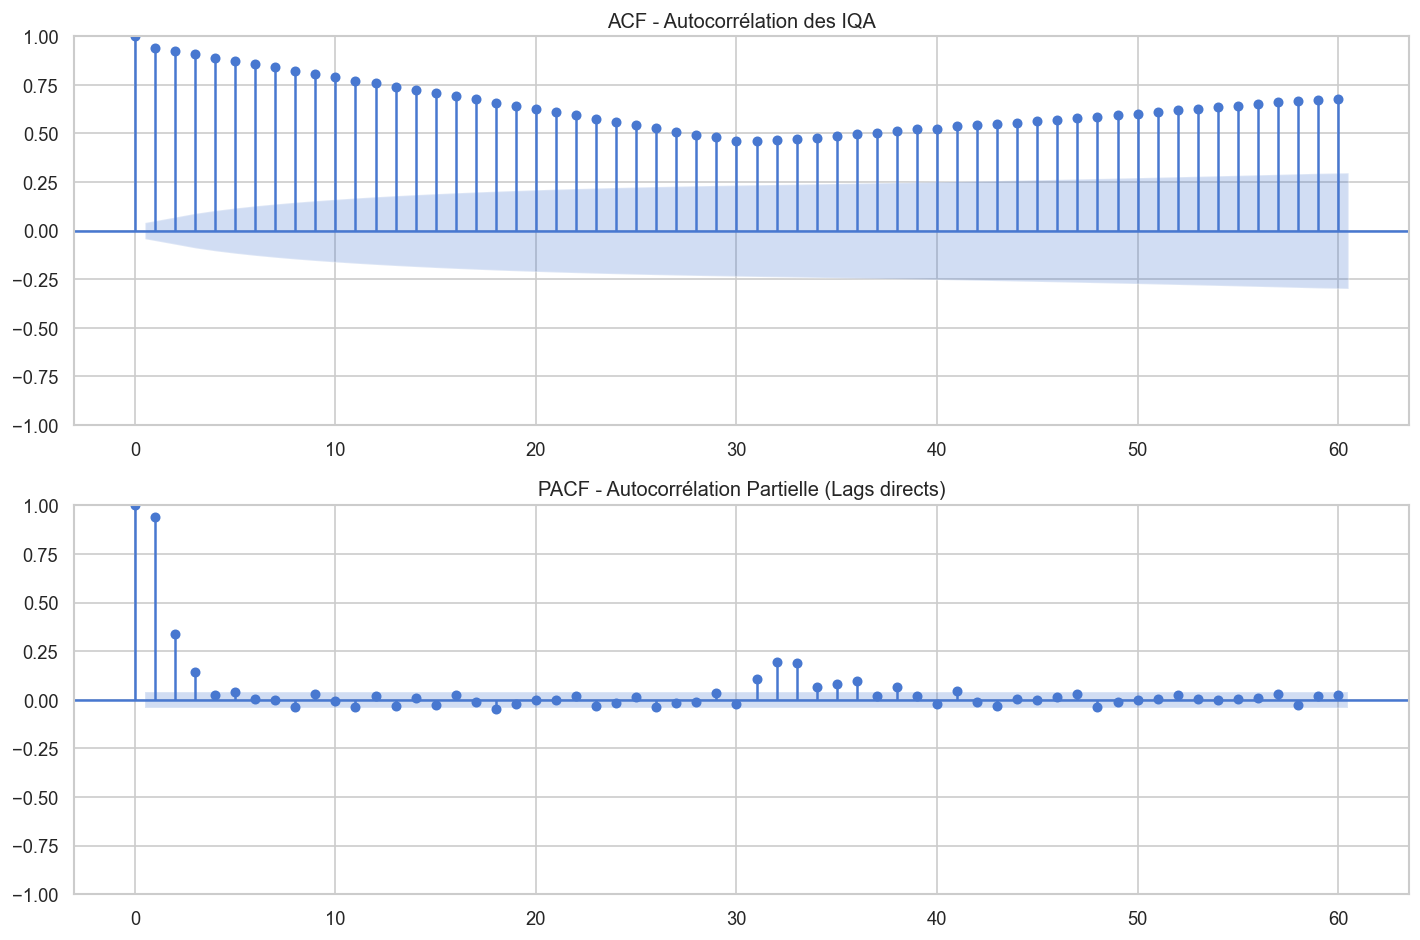

In [17]:
# On choisit une ville parmis les villes (les villes sont equilibrés)
city_sample = df_feat[df_feat['city_enc'] == 0]['iqa_global']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# ACF : Corrélation totale
sm.graphics.tsa.plot_acf(city_sample, lags=60, ax=ax1)
ax1.set_title("ACF - Autocorrélation des IQA")

# PACF : Corrélation directe pour voir les meilleurs lags
sm.graphics.tsa.plot_pacf(city_sample, lags=60, ax=ax2, method='ywm')
ax2.set_title("PACF - Autocorrélation Partielle (Lags directs)")

plt.tight_layout()
plt.show()

ceci nous indique :

ACF (Autocorrélation) : La décroissance est très lente. Cela signifie que la valeur d'aujourd'hui est corrélée avec celle d'il y a 10, 20, voire 60 jours.

PACF (Autocorrélation Partielle) : On voit que les pics sont significatifs (au-dessus de la zone bleue) jusqu'au Lag 5 ou 6, puis s'effondrent.

Action : On doit impérativement créer au moins 5 colonnes de Lags (t-1 à t-5). Le Lag 1 est ultra-dominant (proche de 1.0),

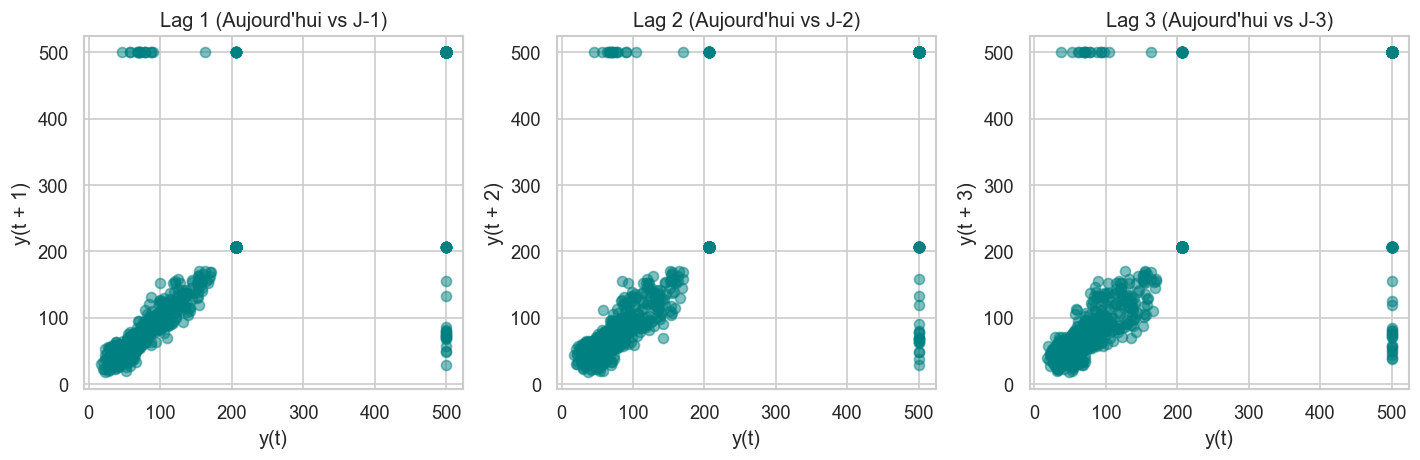

In [18]:
from pandas.plotting import lag_plot
plt.figure(figsize=(12, 4))
for i, lag in enumerate([1, 2, 3], 1):
    plt.subplot(1, 3, i)
    lag_plot(city_sample, lag=lag, c='teal', alpha=0.5)
    plt.title(f'Lag {lag} (Aujourd\'hui vs J-{lag})')

plt.tight_layout()
plt.show()

Ces graphiques de corrélation (nuages de points) confirment visuellement la PACF.On voit une ligne diagonale très nette pour le Lag 1, qui commence à s'élargir (plus de bruit) pour le Lag 2 et Lag 3.

La corrélation est très forte à J-1.

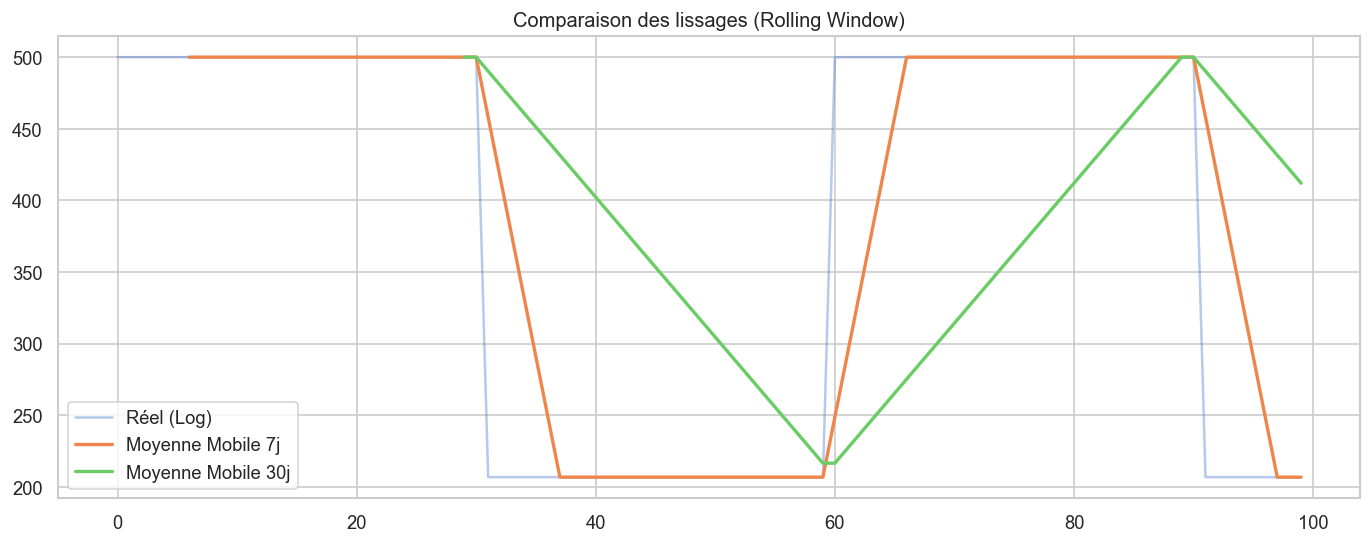

In [19]:
plt.figure(figsize=(14, 5))
plt.plot(city_sample.values[:100], label='Réel (Log)', alpha=0.4)
plt.plot(city_sample.rolling(window=7).mean().values[:100], label='Moyenne Mobile 7j', lw=2)
plt.plot(city_sample.rolling(window=30).mean().values[:100], label='Moyenne Mobile 30j', lw=2)

plt.title("Comparaison des lissages (Rolling Window)")
plt.legend()
plt.show()

Moyenne Mobile 7j (Orange) : Elle suit d'assez près les changements brusques (les "marches" dans les données). Elle capte la tendance hebdomadaire. C'est crucial au Cameroun pour détecter l'arrivée d'une nappe de poussière (Harmattan) qui dure généralement une semaine.

Moyenne Mobile 30j (Vert) : Elle est beaucoup plus lisse et "lente". Elle ne réagit pas aux pics quotidiens mais montre la tendance saisonnière.

In [21]:
# Les lag features utilisent
df_feat = df_feat.sort_values(['city', 'time'])

for lag in [1,2,3, 7,14,30]:
    df_feat[f'iqa_global_lag_{lag}'] = (
        df_feat.groupby('city')[TARGET].shift(lag)
    )

# Rolling means (fenêtre glissante)
for window in [7, 30]:
    df_feat[f'iqa_global_roll_{window}'] = (
        df_feat.groupby('city')[TARGET]
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )

# Rolling std 7j (volatilité locale)
df_feat['iqa_global_roll_std7'] = (
    df_feat.groupby('city')[TARGET]
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).std().fillna(0))
)

n_before = len(df_feat)
df_feat  = df_feat.dropna(subset=[f'iqa_global_lag_{lag}' for lag in [1,3,7,14]]).reset_index(drop=True)
n_after  = len(df_feat)

print(f'✅ Lag features + rolling means ajoutés')
print(f'   Lignes supprimées (NaN lag) : {n_before - n_after:,}')
print(f'   Dataset final : {n_after:,} lignes')

✅ Lag features + rolling means ajoutés
   Lignes supprimées (NaN lag) : 560
   Dataset final : 86,680 lignes


---
## ✂️  3. Sélection des features & split Train/Test

In [ ]:
#Colonnes derive
col_derive=['temperature_2m_max','temperature_2m_min','sunshine_duration','daylight_duration','wind_speed_10m_max','precipitation_sum','city','region','saison',
'o3_mean','o3_max', 'o3_min', 'o3_p95', 'no2_mean', 'no2_max', 'no2_min','no2_p95', 'qualite_pm25', 'alerte_pm25', 'qualite_o3', 'alerte_o3','qualite_no2', 'alerte_no2','iqa_pm25', 'iqa_o3',
'iqa_no2', 'polluant_directeur', 'iqa_label','alerte_iqa','pm25_mean','indice_global']
#Colonnes qui n'apportent rien
col_inutiles=['id']
#Colonnes fortement correle avec la target
col_corr=['pm25_max','pm25_min','pm25_p95']
#Colonnes temporelles brutes
col_temp=['sunrise','sunset','year']
#Colonnes presque target
col_target=['alerte_pm25']

#Suppression de ces colonnes
df_feat=df_feat.drop(columns=col_inutiles+col_corr+col_temp+col_target+col_derive)

Analyse de la correlation sur la variable cible

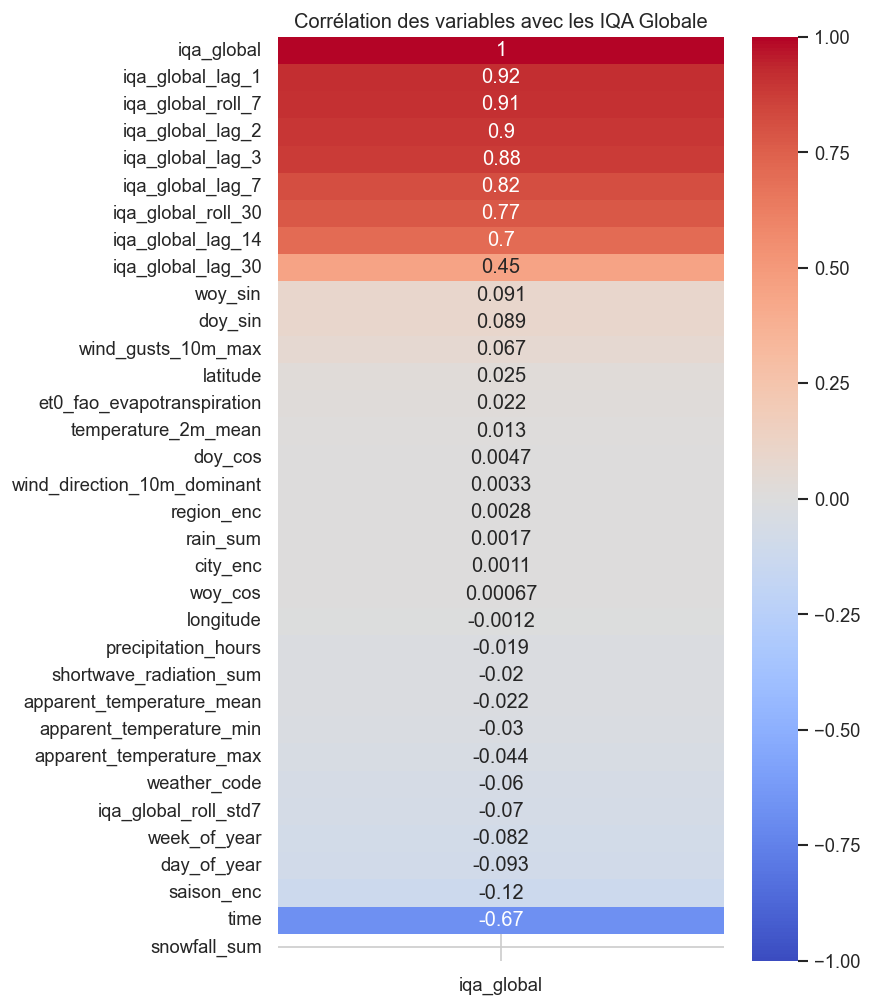

In [25]:
plt.figure(figsize=(6, 10))
correlation_matrix = df_feat.corr()
sns.heatmap(correlation_matrix[['iqa_global']].sort_values(by='iqa_global', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Corrélation des variables avec les IQA Globale")
plt.show()

In [26]:
col_not_correlate=['doy_cos','woy_cos','rain_sum','longitude','wind_direction_10m_dominant','region_enc','city_enc','snowfall_sum']
df_feat.drop(columns=col_not_correlate,inplace=True)

Visualisation des correlations entre variables

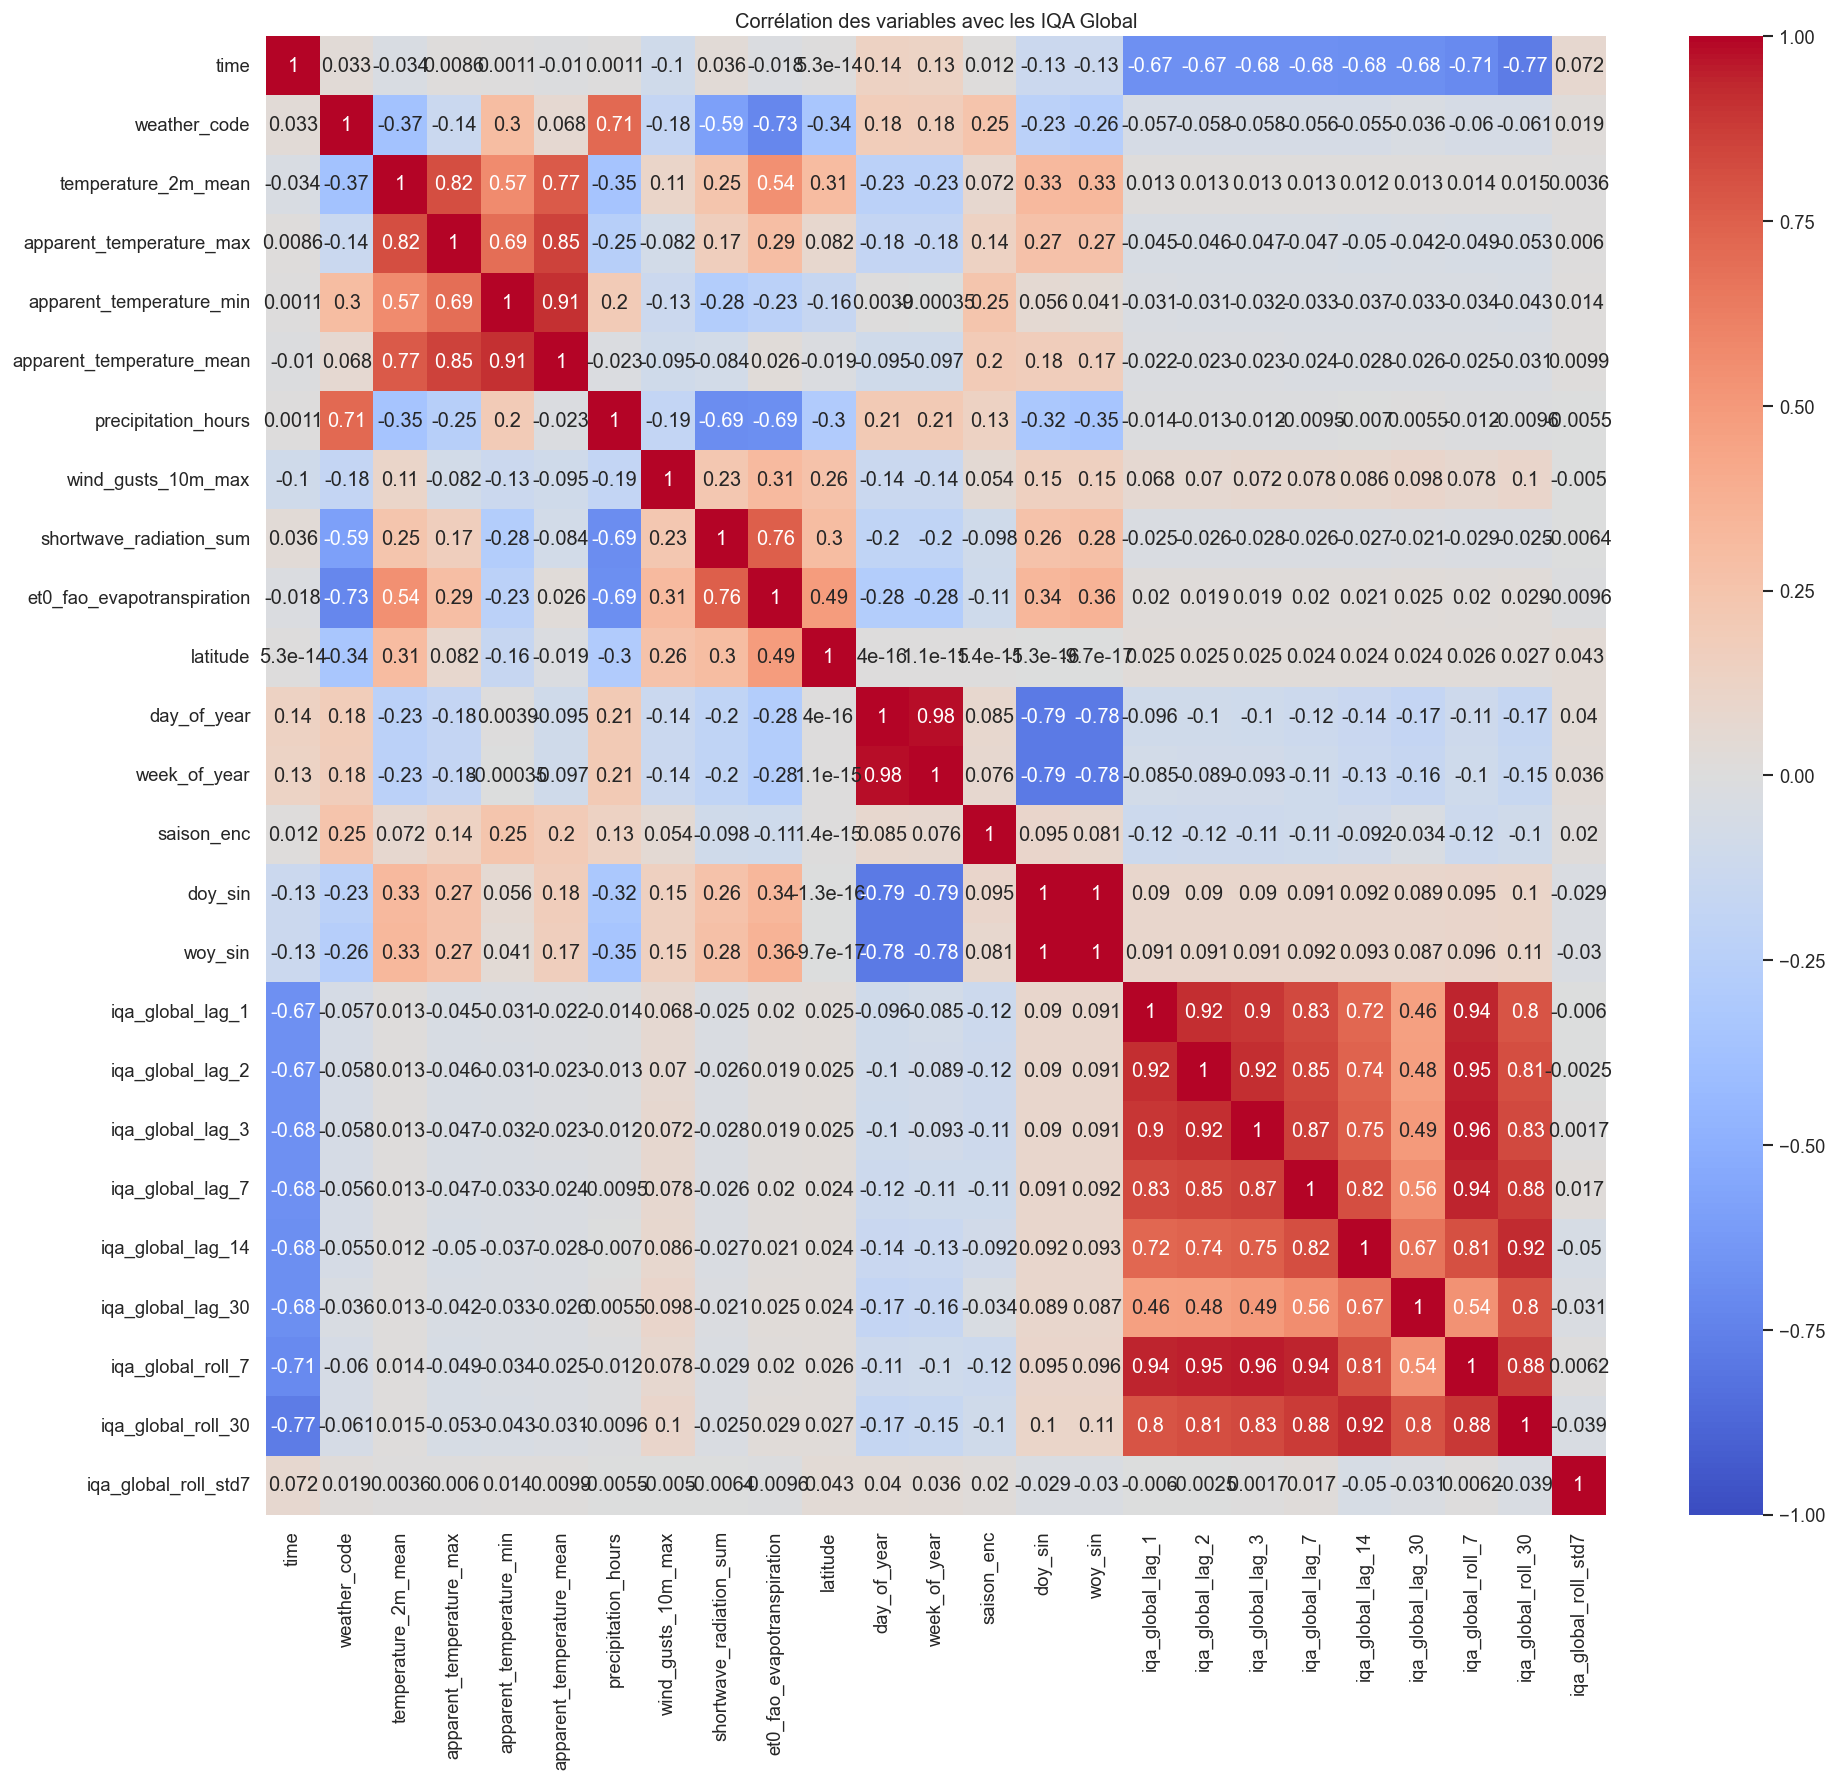

In [28]:
plt.figure(figsize=(18, 16))
sns.heatmap(df_feat.drop(columns=["iqa_global"]).corr(),annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Corrélation des variables avec les IQA Global")
plt.show()

In [29]:
#Variables fortement correles
col_corr=['woy_sin','day_of_year','week_of_year','apparent_temperature_min']
df_feat.drop(columns=col_corr,inplace=True)

In [31]:
# Colonnes à exclure :
# - temps (pour éviter les fuites temporelles, on ne veut pas que le modèle puisse "voir" le temps exact de la prédiction)
COLS_EXCLUDE = ['time', TARGET]                                             # la cible elle-même

FEATURES = [c for c in df_feat.columns if c not in COLS_EXCLUDE]

print(f'📋 Nombre de features retenues : {len(FEATURES)}')
print('\n'.join(f'   • {f}' for f in FEATURES))

📋 Nombre de features retenues : 20
   • weather_code
   • temperature_2m_mean
   • apparent_temperature_max
   • apparent_temperature_mean
   • precipitation_hours
   • wind_gusts_10m_max
   • shortwave_radiation_sum
   • et0_fao_evapotranspiration
   • latitude
   • saison_enc
   • doy_sin
   • iqa_global_lag_1
   • iqa_global_lag_2
   • iqa_global_lag_3
   • iqa_global_lag_7
   • iqa_global_lag_14
   • iqa_global_lag_30
   • iqa_global_roll_7
   • iqa_global_roll_30
   • iqa_global_roll_std7


In [32]:
df_feat[FEATURES] = df_feat[FEATURES].fillna(df_feat['iqa_global_lag_30'].mean())  # Vérification des NaN restants

In [33]:
X = df_feat[FEATURES]
y = df_feat[TARGET]

# Split temporel → shuffle=False pour respecter l'ordre chronologique
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f'✅ Split Train/Test (80/20) — shuffle=False (ordre temporel conservé)')
print(f'   Train : {X_train.shape[0]:,} observations')
print(f'   Test  : {X_test.shape[0]:,} observations')
print(f'\n   Target — Train | mean={y_train.mean():.2f}  std={y_train.std():.2f}')
print(f'   Target — Test  | mean={y_test.mean():.2f}  std={y_test.std():.2f}')

✅ Split Train/Test (80/20) — shuffle=False (ordre temporel conservé)
   Train : 69,344 observations
   Test  : 17,336 observations

   Target — Train | mean=205.50  std=179.38
   Target — Test  | mean=201.98  std=182.06


---
## 📐 4. Fonction d'évaluation commune

In [51]:
def evaluate_model(name, y_true, y_pred):
    """Calcule et affiche MAE, RMSE, R² pour un modèle."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'  [{name}]')
    print(f'    MAE  = {mae:.4f} µg/m³')
    print(f'    RMSE = {rmse:.4f} µg/m³')
    print(f'    R²   = {r2:.4f}')
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []   # stockage des métriques pour la comparaison finale
print('✅ Fonction evaluate_model définie')

✅ Fonction evaluate_model définie


---
## 🔵 5. Modèle 1 — Régression Linéaire (baseline)

  MODÈLE 1 — Régression Linéaire (Ridge)
  [Ridge Regression]
    MAE  = 24.7931 µg/m³
    RMSE = 66.4740 µg/m³
    R²   = 0.8667


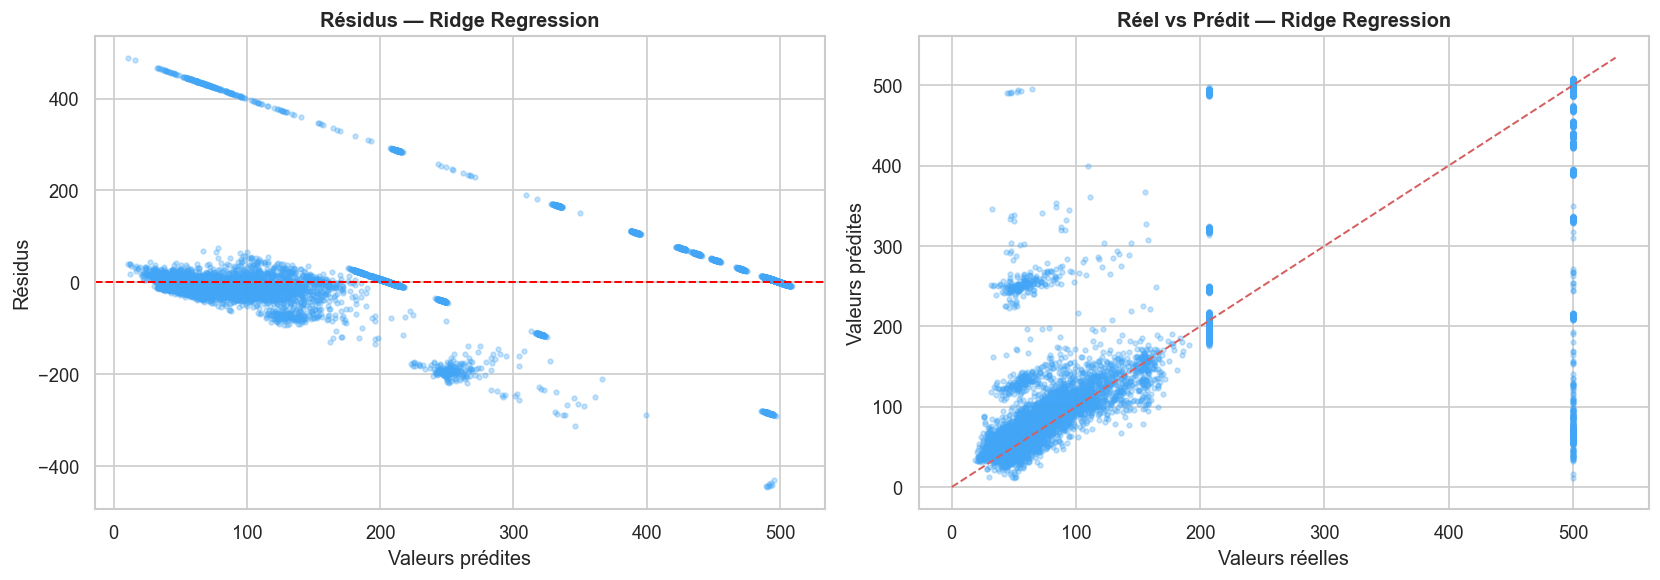

In [52]:
print('='*50)
print('  MODÈLE 1 — Régression Linéaire (Ridge)')
print('='*50)

# Pipeline avec scaling (obligatoire pour la régression linéaire)
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=1.0))
])

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

res_lr = evaluate_model('Ridge Regression', y_test, y_pred_lr)
results.append(res_lr)

# Résidus
residuals_lr = y_test - y_pred_lr
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_lr, residuals_lr, alpha=0.3, s=8, color='#42A5F5')
axes[0].axhline(0, color='red', linewidth=1.2, linestyle='--')
axes[0].set_xlabel('Valeurs prédites')
axes[0].set_ylabel('Résidus')
axes[0].set_title('Résidus — Ridge Regression', fontweight='bold')

axes[1].scatter(y_test, y_pred_lr, alpha=0.3, s=8, color='#42A5F5')
lim = max(y_test.max(), y_pred_lr.max()) * 1.05
axes[1].plot([0, lim], [0, lim], 'r--', linewidth=1.2)
axes[1].set_xlabel('Valeurs réelles')
axes[1].set_ylabel('Valeurs prédites')
axes[1].set_title('Réel vs Prédit — Ridge Regression', fontweight='bold')

plt.tight_layout()
plt.savefig('images/plot_10_ridge_eval.png', bbox_inches='tight')
plt.show()

---
## 🟢 6. Modèle 2 — Random Forest

  MODÈLE 2 — Random Forest
  [Random Forest]
    MAE  = 14.8207 µg/m³
    RMSE = 51.2435 µg/m³
    R²   = 0.9208


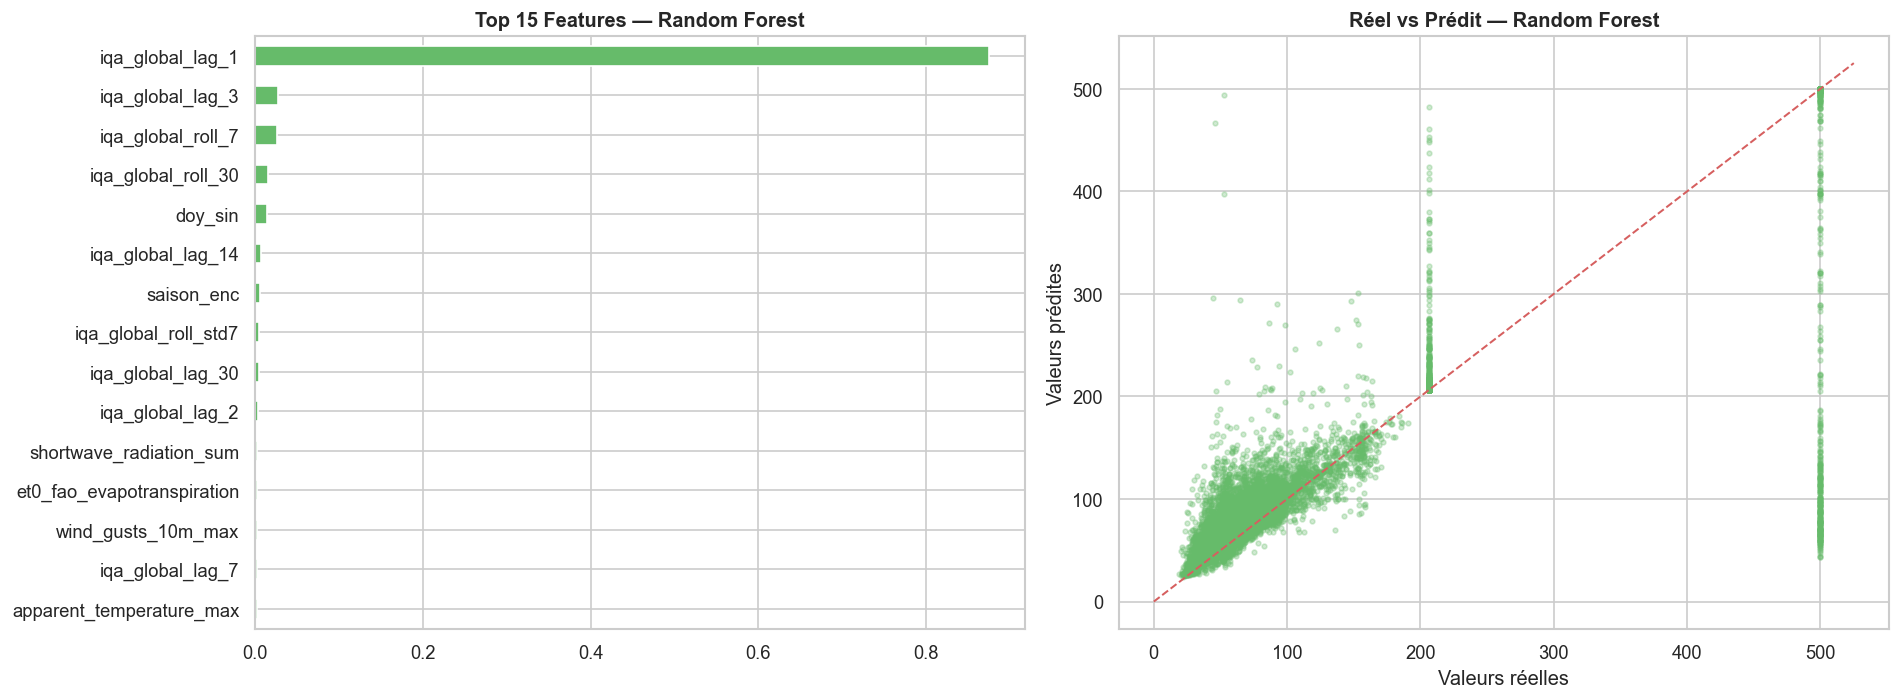

In [53]:
print('='*50)
print('  MODÈLE 2 — Random Forest')
print('='*50)

rf = RandomForestRegressor(
    n_estimators = 1000,
    max_depth    = 30,
    min_samples_leaf = 4,
    n_jobs       = -1,
    random_state = RANDOM_STATE
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

res_rf = evaluate_model('Random Forest', y_test, y_pred_rf)
results.append(res_rf)

# Feature importance
feat_imp_rf = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feat_imp_rf.head(15).plot(kind='barh', ax=axes[0], color='#66BB6A', edgecolor='white')
axes[0].set_title('Top 15 Features — Random Forest', fontweight='bold')
axes[0].invert_yaxis()

axes[1].scatter(y_test, y_pred_rf, alpha=0.3, s=8, color='#66BB6A')
lim = max(y_test.max(), y_pred_rf.max()) * 1.05
axes[1].plot([0, lim], [0, lim], 'r--', linewidth=1.2)
axes[1].set_xlabel('Valeurs réelles')
axes[1].set_ylabel('Valeurs prédites')
axes[1].set_title('Réel vs Prédit — Random Forest', fontweight='bold')

plt.tight_layout()
plt.savefig('images/plot_11_rf_eval.png', bbox_inches='tight')
plt.show()

---
## 🔴 7. Modèle 3 — XGBoost & LightGBM

  MODÈLE 3a — XGBoost
   Nombre d'arbres utilisés (early stopping) : 91
  [XGBoost]
    MAE  = 15.9916 µg/m³
    RMSE = 52.0144 µg/m³
    R²   = 0.9184


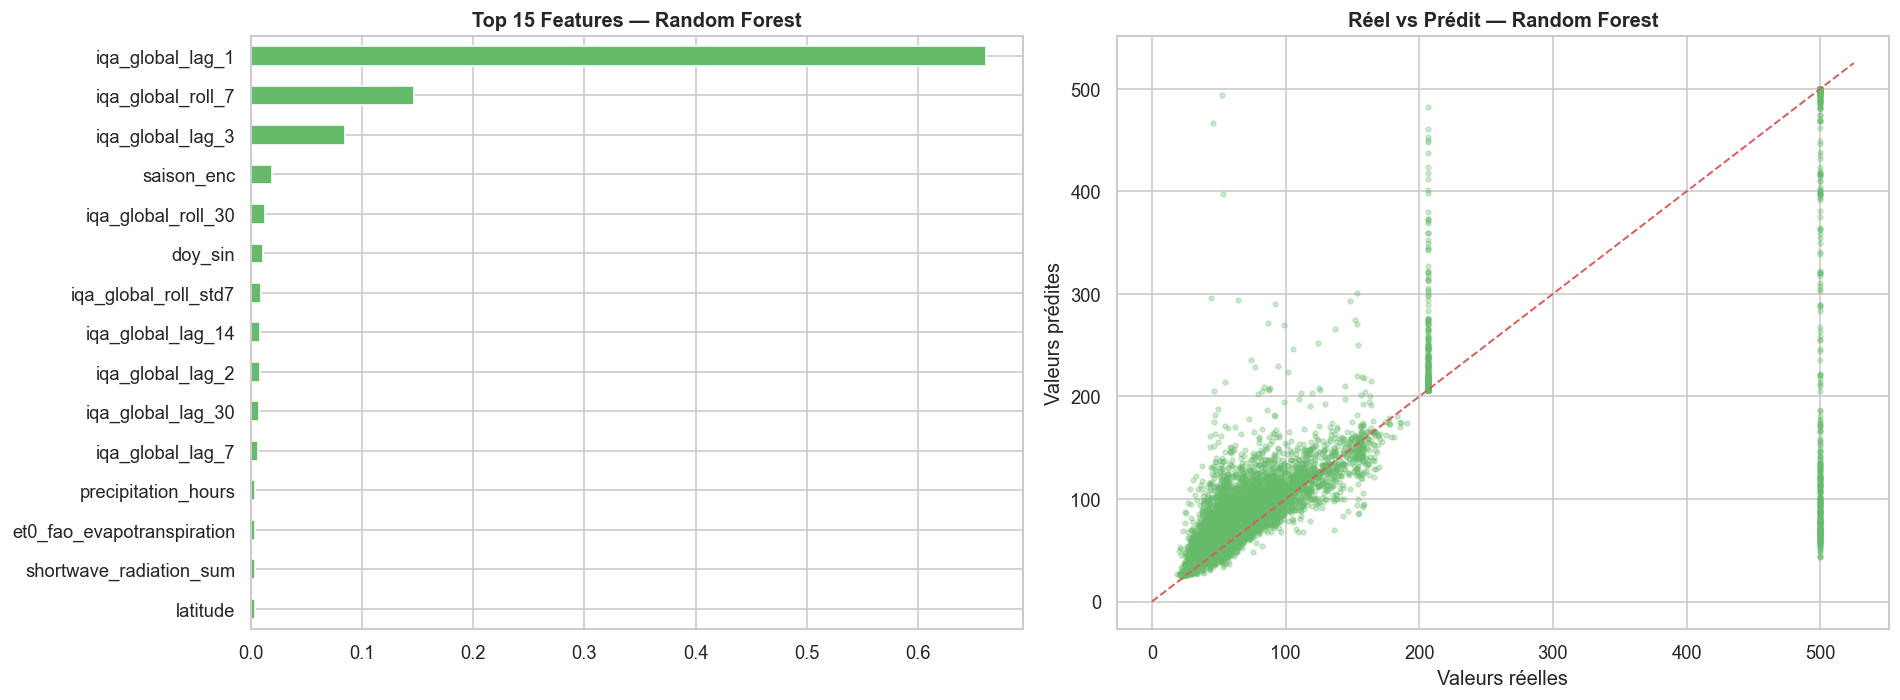

In [54]:
print('='*50)
print('  MODÈLE 3a — XGBoost')
print('='*50)

# Split interne pour early stopping (10% du train)
split_idx  = int(len(X_train) * 0.9)
X_tr, X_val = X_train.iloc[:split_idx], X_train.iloc[split_idx:]
y_tr, y_val = y_train.iloc[:split_idx], y_train.iloc[split_idx:]

xgb = XGBRegressor(
    n_estimators      = 1000,
    learning_rate     = 0.05,
    max_depth         = 10,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    early_stopping_rounds = 50,
    eval_metric       = 'rmse',
    random_state      = RANDOM_STATE,
    verbosity         = 0
)
xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
y_pred_xgb = xgb.predict(X_test)

print(f'   Nombre d\'arbres utilisés (early stopping) : {xgb.best_iteration}')
res_xgb = evaluate_model('XGBoost', y_test, y_pred_xgb)
results.append(res_xgb)

# Feature importance
feat_imp_xgb = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feat_imp_xgb.head(15).plot(kind='barh', ax=axes[0], color='#66BB6A', edgecolor='white')
axes[0].set_title('Top 15 Features — Random Forest', fontweight='bold')
axes[0].invert_yaxis()

axes[1].scatter(y_test, y_pred_rf, alpha=0.3, s=8, color='#66BB6A')
lim = max(y_test.max(), y_pred_rf.max()) * 1.05
axes[1].plot([0, lim], [0, lim], 'r--', linewidth=1.2)
axes[1].set_xlabel('Valeurs réelles')
axes[1].set_ylabel('Valeurs prédites')
axes[1].set_title('Réel vs Prédit — Random Forest', fontweight='bold')

plt.tight_layout()
plt.savefig('images/plot_11_rf_eval.png', bbox_inches='tight')
plt.show()

  MODÈLE 3b — LightGBM
  [LightGBM]
    MAE  = 16.0254 µg/m³
    RMSE = 51.6997 µg/m³
    R²   = 0.9194


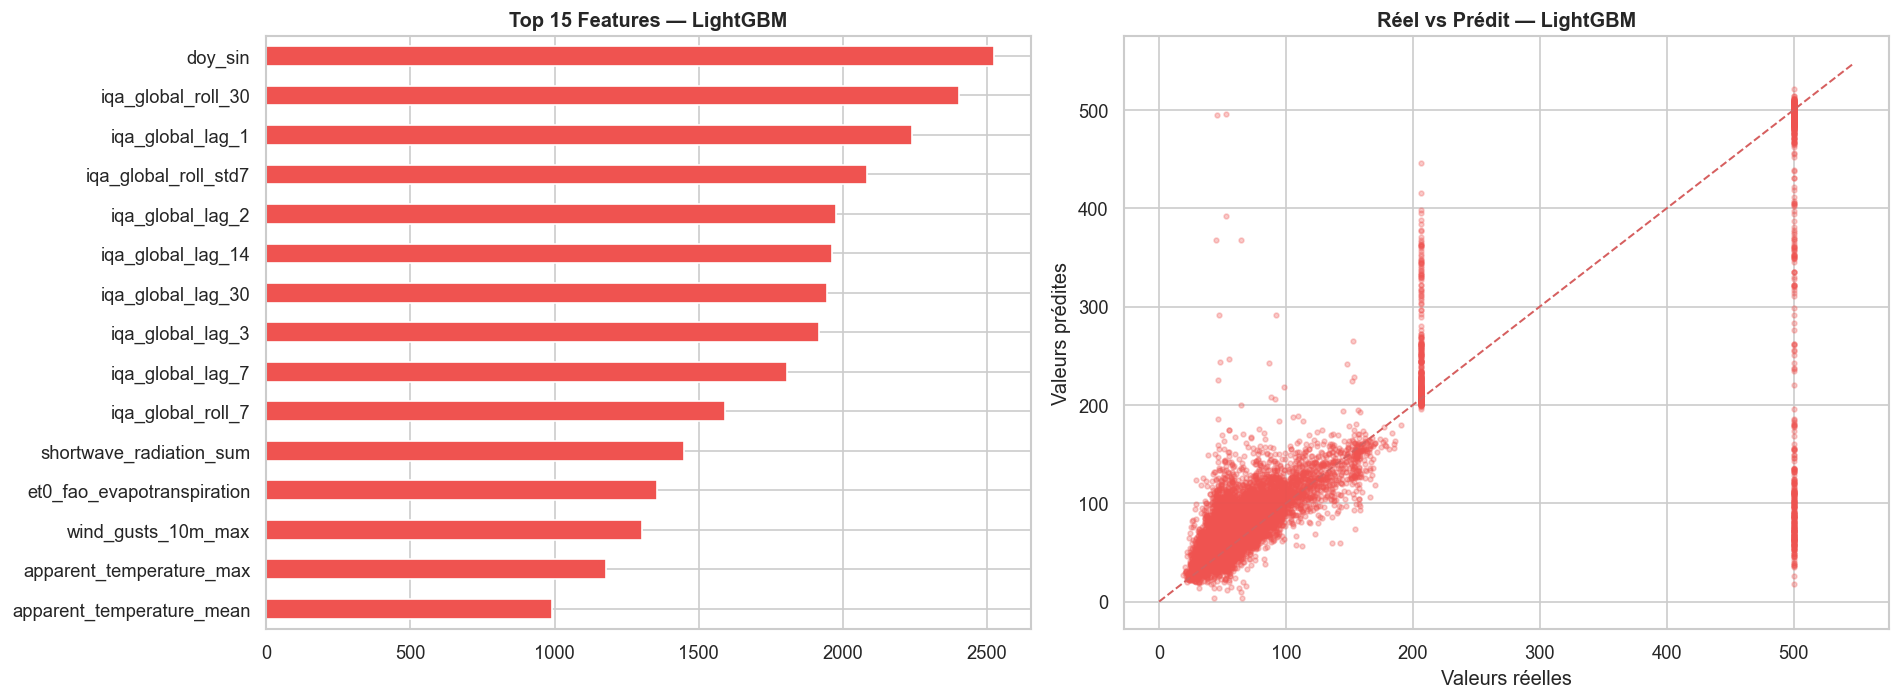

In [55]:
print('='*50)
print('  MODÈLE 3b — LightGBM')
print('='*50)

lgbm = LGBMRegressor(
    n_estimators     = 1000,
    learning_rate    = 0.05,
    max_depth        = 10,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = RANDOM_STATE,
    verbose          = -1
)
lgbm.fit(
    X_tr, y_tr,
    eval_set     = [(X_val, y_val)],
    callbacks    = []
)
y_pred_lgbm = lgbm.predict(X_test)

res_lgbm = evaluate_model('LightGBM', y_test, y_pred_lgbm)
results.append(res_lgbm)

# Feature importance LightGBM
feat_imp_lgbm = pd.Series(
    lgbm.feature_importances_, index=FEATURES
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
feat_imp_lgbm.head(15).plot(kind='barh', ax=axes[0], color='#EF5350', edgecolor='white')
axes[0].set_title('Top 15 Features — LightGBM', fontweight='bold')
axes[0].invert_yaxis()

axes[1].scatter(y_test, y_pred_lgbm, alpha=0.3, s=8, color='#EF5350')
lim = max(y_test.max(), y_pred_lgbm.max()) * 1.05
axes[1].plot([0, lim], [0, lim], 'r--', linewidth=1.2)
axes[1].set_xlabel('Valeurs réelles')
axes[1].set_ylabel('Valeurs prédites')
axes[1].set_title('Réel vs Prédit — LightGBM', fontweight='bold')

plt.tight_layout()
plt.savefig('images/plot_12_lgbm_eval.png', bbox_inches='tight')
plt.show()

In [56]:
results

[{'model': 'Ridge Regression',
  'MAE': 24.79307596633432,
  'RMSE': np.float64(66.47401812080709),
  'R2': 0.8666783183022627},
 {'model': 'Random Forest',
  'MAE': 14.820656943252484,
  'RMSE': np.float64(51.24351725880244),
  'R2': 0.9207727132120443},
 {'model': 'XGBoost',
  'MAE': 15.99162282362866,
  'RMSE': np.float64(52.014392179911106),
  'R2': 0.918371093907055},
 {'model': 'LightGBM',
  'MAE': 16.025396084754803,
  'RMSE': np.float64(51.699692860482905),
  'R2': 0.9193558540550828}]

---
## 📊 8. Comparaison des modèles

In [57]:
df_results = pd.DataFrame(results[:4]).set_index('model').round(4)
df_results['Rank_MAE']  = df_results['MAE'].rank().astype(int)
df_results['Rank_R2']   = df_results['R2'].rank(ascending=False).astype(int)

print('\n📋 TABLEAU COMPARATIF DES MODÈLES')
print('='*55)
display(df_results.style
    .background_gradient(cmap='RdYlGn', subset=['R2'])
    .background_gradient(cmap='RdYlGn_r', subset=['MAE', 'RMSE'])
    .format({'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'R2': '{:.4f}'})
)

best_model_name = df_results['R2'].idxmax()
print(f'\n🏆 Meilleur modèle (R²) : {best_model_name}')


📋 TABLEAU COMPARATIF DES MODÈLES


,MAE,RMSE,R2,Rank_MAE,Rank_R2
model,,,,,
Ridge Regression,24.7931,66.4740,0.8667,4,4
Random Forest,14.8207,51.2435,0.9208,1,1
XGBoost,15.9916,52.0144,0.9184,2,3
LightGBM,16.0254,51.6997,0.9194,3,2



🏆 Meilleur modèle (R²) : Random Forest


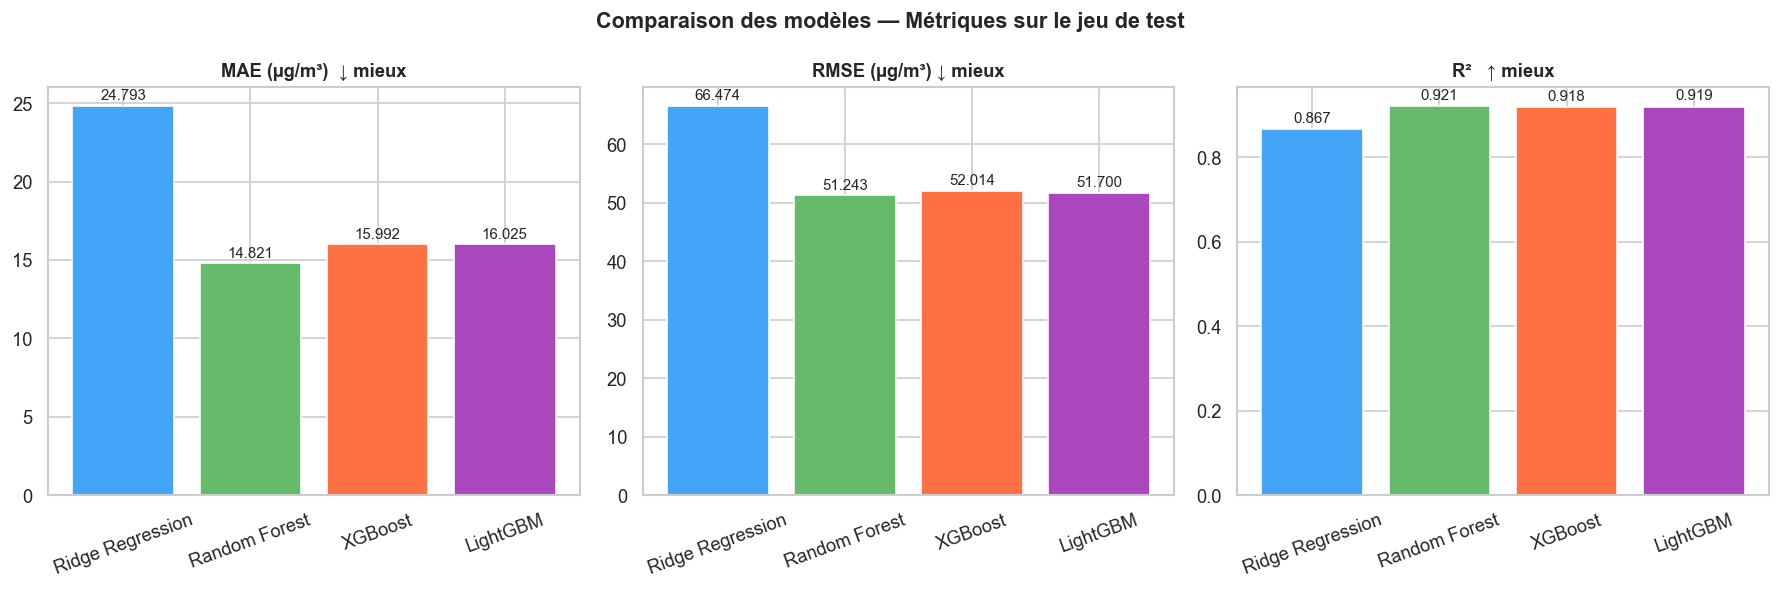

In [58]:
# Graphique comparatif MAE / RMSE / R²
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparaison des modèles — Métriques sur le jeu de test', fontsize=13, fontweight='bold')

model_names = df_results.index.tolist()
colors      = ['#42A5F5', '#66BB6A', '#FF7043', '#AB47BC']

for ax, metric, label, cmap_inv in zip(
    axes,
    ['MAE', 'RMSE', 'R2'],
    ['MAE (µg/m³)  ↓ mieux', 'RMSE (µg/m³) ↓ mieux', 'R²   ↑ mieux'],
    [True, True, False]
):
    vals  = df_results[metric].values
    bars  = ax.bar(model_names, vals, color=colors[:len(model_names)], edgecolor='white')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    # Valeur au sommet de chaque barre
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('images/plot_13_comparaison_modeles.png', bbox_inches='tight')
plt.show()

---
## 📈 9. Courbe temporelle — Réel vs Prédit (meilleur modèle)

In [60]:
df_feat.columns

Index(['time', 'weather_code', 'temperature_2m_mean',
       'apparent_temperature_max', 'apparent_temperature_mean',
       'precipitation_hours', 'wind_gusts_10m_max', 'shortwave_radiation_sum',
       'et0_fao_evapotranspiration', 'latitude', 'iqa_global', 'saison_enc',
       'doy_sin', 'iqa_global_lag_1', 'iqa_global_lag_2', 'iqa_global_lag_3',
       'iqa_global_lag_7', 'iqa_global_lag_14', 'iqa_global_lag_30',
       'iqa_global_roll_7', 'iqa_global_roll_30', 'iqa_global_roll_std7'],
      dtype='object')

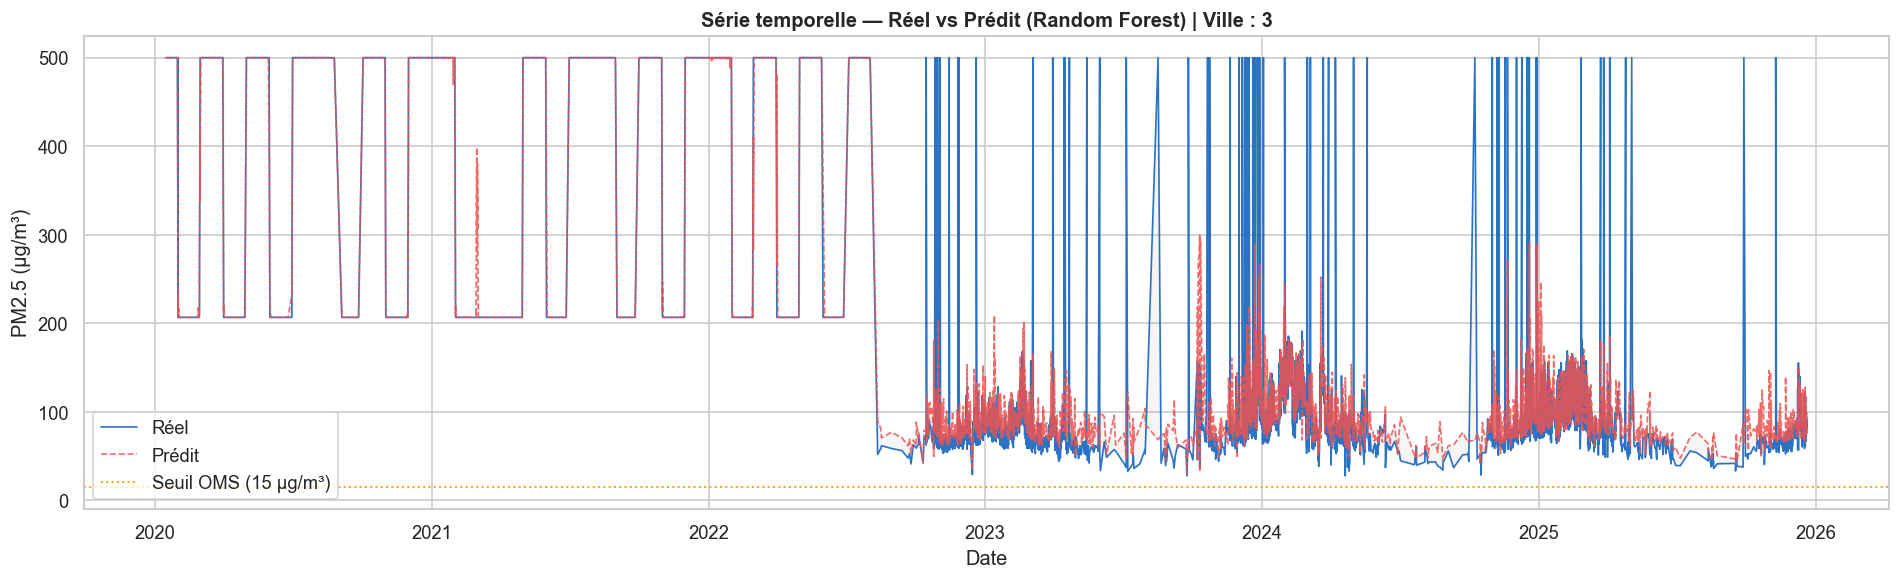

MAE sur 3 : 14.547 µg/m³


In [62]:
# Sélection automatique du meilleur modèle
preds = {
    'Ridge Regression': y_pred_lr,
    'Random Forest'   : y_pred_rf,
    'XGBoost'         : y_pred_xgb,
    'LightGBM'        : y_pred_lgbm,
}
best_pred = preds[best_model_name]

# Prendre une ville représentative pour la visualisation
test_idx    = X_test.index
df_test_viz = df_feat.loc[test_idx].copy()
df_test_viz['y_true'] = y_test.values
df_test_viz['y_pred'] = best_pred

# Choisir la ville avec le plus d'observations dans le test
best_weather = df_test_viz['weather_code'].value_counts().idxmax()
weather_data = df_test_viz[df_test_viz['weather_code'] == best_weather].sort_values('time')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(weather_data['time'], weather_data['y_true'], label='Réel',  color='#1565C0', linewidth=1, alpha=0.9)
ax.plot(weather_data['time'], weather_data['y_pred'], label='Prédit', color='#EF5350', linewidth=1, linestyle='--', alpha=0.85)
ax.axhline(15, color='orange', linestyle=':', linewidth=1.2, label='Seuil OMS (15 µg/m³)')
ax.fill_between(weather_data['time'], weather_data['y_true'], weather_data['y_pred'], alpha=0.08, color='gray')
ax.set_title(f'Série temporelle — Réel vs Prédit ({best_model_name}) | Ville : {best_weather}',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.legend()
plt.tight_layout()
plt.savefig('images/plot_14_serie_temporelle.png', bbox_inches='tight')
plt.show()

mae_city = mean_absolute_error(weather_data['y_true'], weather_data['y_pred'])
print(f'MAE sur {best_weather} : {mae_city:.3f} µg/m³')

In [63]:
best_model=rf

⚠️  SHAP non installé — pip install shap


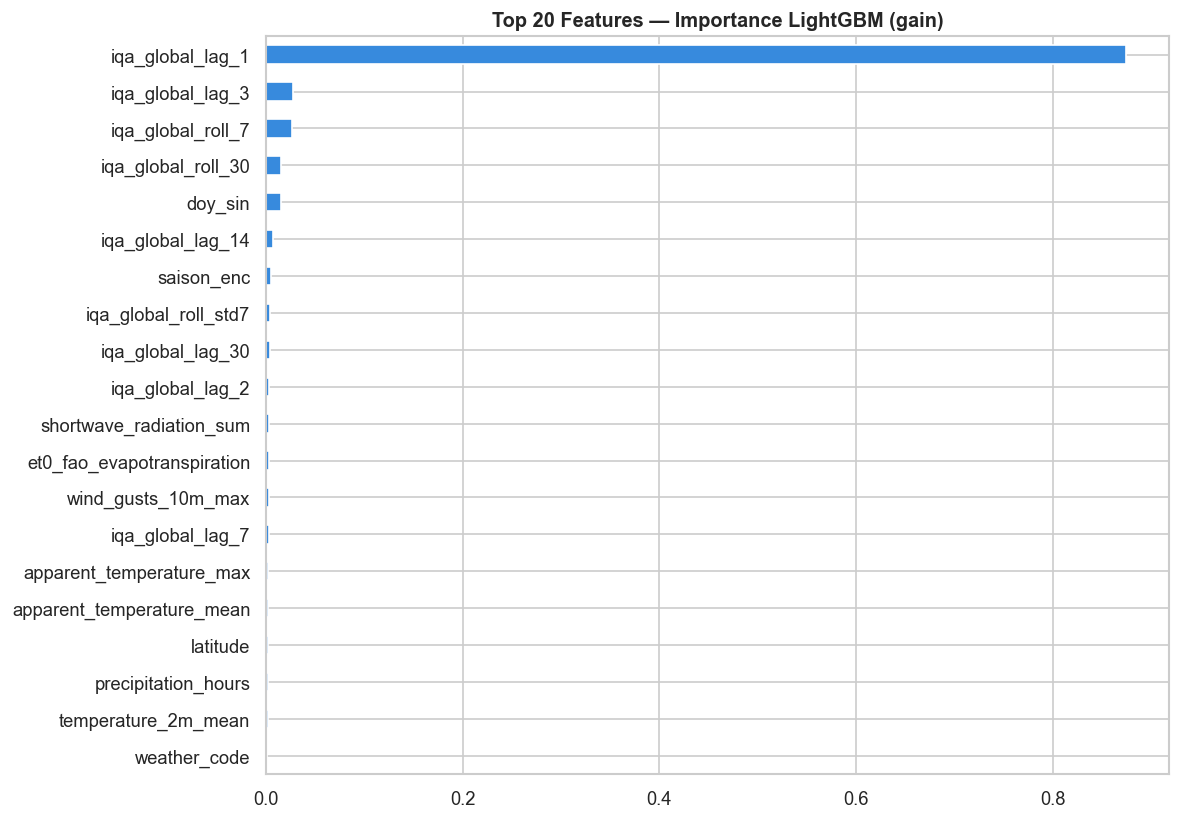

In [68]:
try:
    import shap
    sample_size = min(2000, len(X_test))
    X_shap      = X_test.sample(sample_size, random_state=RANDOM_STATE)
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_shap)

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
    plt.title('SHAP — Impact des features sur la qualite de l air(IQA_global)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_16_shap_summary.png', bbox_inches='tight')
    plt.show()

    print('Top 10 features (SHAP) :')
    shap_imp = pd.DataFrame({'feature': FEATURES,
                             'shap_mean': np.abs(shap_values).mean(axis=0)
                            }).sort_values('shap_mean', ascending=False)
    print(shap_imp.head(10).to_string(index=False))

except ImportError:
    print('⚠️  SHAP non installé — pip install shap')
    feat_imp = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False).head(20)
    fig, ax  = plt.subplots(figsize=(10, 7))
    feat_imp.plot(kind='barh', ax=ax, color='#378ADD', edgecolor='white')
    ax.set_title('Top 20 Features — Importance LightGBM (gain)', fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('images/plot_16_feature_importance.png', bbox_inches='tight')
    plt.show()

In [72]:
feat_imp_rf.sort_values(ascending=False).head(14)

iqa_global_lag_1              0.874590
iqa_global_lag_3              0.027160
iqa_global_roll_7             0.026365
iqa_global_roll_30            0.015148
doy_sin                       0.014608
iqa_global_lag_14             0.007236
saison_enc                    0.005217
iqa_global_roll_std7          0.004083
iqa_global_lag_30             0.003982
iqa_global_lag_2              0.002867
shortwave_radiation_sum       0.002638
et0_fao_evapotranspiration    0.002556
wind_gusts_10m_max            0.002551
iqa_global_lag_7              0.002464
dtype: float64

In [73]:
FEATURES_NEW = feat_imp_rf.sort_values(ascending=False).head(14).index.tolist()

In [74]:
X_NEW = df_feat[FEATURES_NEW]
y = df_feat[TARGET]

# Split temporel → shuffle=False pour respecter l'ordre chronologique
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_NEW, y, test_size=0.2, shuffle=False
)

print(f'✅ Split Train/Test (80/20) — shuffle=False (ordre temporel conservé)')
print(f'   Train : {X_train_new.shape[0]:,} observations')
print(f'   Test  : {X_test_new.shape[0]:,} observations')
print(f'\n   Target — Train | mean={y_train_new.mean():.2f}  std={y_train_new.std():.2f}')
print(f'   Target — Test  | mean={y_test_new.mean():.2f}  std={y_test_new.std():.2f}')

✅ Split Train/Test (80/20) — shuffle=False (ordre temporel conservé)
   Train : 69,344 observations
   Test  : 17,336 observations

   Target — Train | mean=205.50  std=179.38
   Target — Test  | mean=201.98  std=182.06


  MODÈLE 2 — Random Forest
  [Random Forest_op]
    MAE  = 14.5883 µg/m³
    RMSE = 51.3225 µg/m³
    R²   = 0.9205


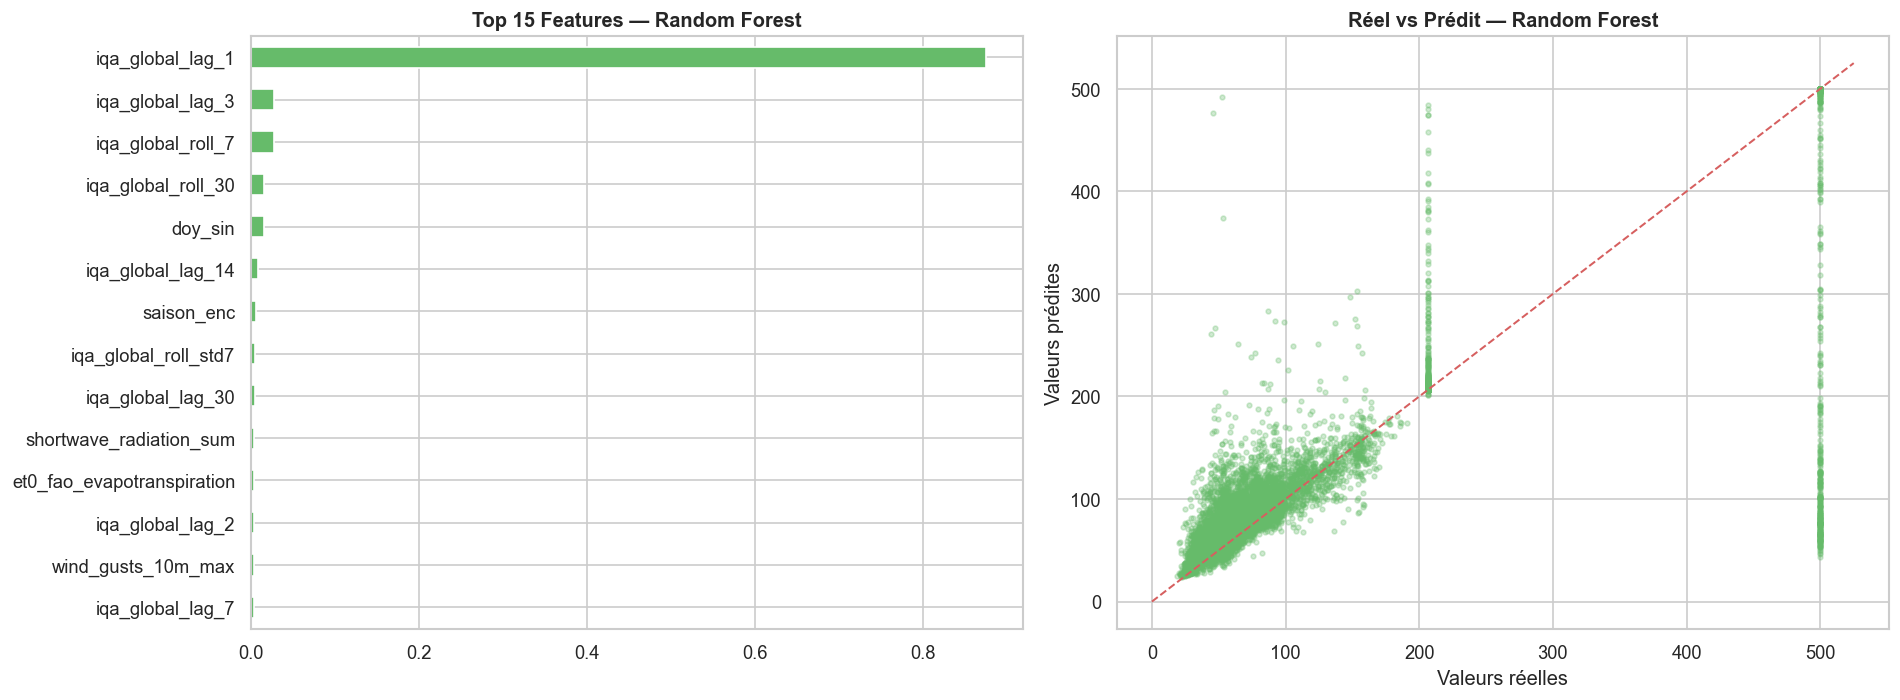

In [76]:
print('='*50)
print('  MODÈLE 2 — Random Forest')
print('='*50)

rf_op = RandomForestRegressor(
    n_estimators = 1000,
    max_depth    = 30,
    min_samples_leaf = 4,
    n_jobs       = -1,
    random_state = RANDOM_STATE
)
rf_op.fit(X_train_new, y_train_new)
y_pred_rf = rf_op.predict(X_test_new)

res_rf = evaluate_model('Random Forest_op', y_test_new, y_pred_rf)
results.append(res_rf)

# Feature importance
feat_imp_rf = pd.Series(rf_op.feature_importances_, index=FEATURES_NEW).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feat_imp_rf.head(15).plot(kind='barh', ax=axes[0], color='#66BB6A', edgecolor='white')
axes[0].set_title('Top 15 Features — Random Forest', fontweight='bold')
axes[0].invert_yaxis()

axes[1].scatter(y_test_new, y_pred_rf, alpha=0.3, s=8, color='#66BB6A')
lim = max(y_test_new.max(), y_pred_rf.max()) * 1.05
axes[1].plot([0, lim], [0, lim], 'r--', linewidth=1.2)
axes[1].set_xlabel('Valeurs réelles')
axes[1].set_ylabel('Valeurs prédites')
axes[1].set_title('Réel vs Prédit — Random Forest', fontweight='bold')

plt.tight_layout()
plt.savefig('images/plot_11_rf_eval.png', bbox_inches='tight')
plt.show()

---
## 💾 10. Sauvegarde du meilleur modèle

In [78]:
best_models = {
    'Ridge Regression': pipe_lr,
    'Random Forest'   : rf,
    'XGBoost'         : xgb,
    'LightGBM'        : lgbm,
}
best_estimator = best_models[best_model_name]

# Sauvegarde modèle + liste de features
joblib.dump(best_estimator, f'model/{best_model_name}_best_model.pkl')
joblib.dump(FEATURES,       f'model/{best_model_name}_features_list.pkl')
joblib.dump(le_city,        f'model/{best_model_name}_encoder_city.pkl')
joblib.dump(le_region,      f'model/{best_model_name}_encoder_region.pkl')
joblib.dump(le_saison,      f'model/{best_model_name}_encoder_saison.pkl')

print(f'✅ Modèle sauvegardé : {best_model_name}_best_model.pkl')
print(f'   Features sauvegardées : {best_model_name}_features_list.pkl ({len(FEATURES)} features)')
print(f'   Encodeurs sauvegardés : {best_model_name}_encoder_city/region/saison.pkl')

✅ Modèle sauvegardé : Random Forest_best_model.pkl
   Features sauvegardées : Random Forest_features_list.pkl (20 features)
   Encodeurs sauvegardés : Random Forest_encoder_city/region/saison.pkl


---
## 📋 11. Récapitulatif final

In [80]:
print('='*65)
print('  RÉCAPITULATIF — MODÉLISATION INDABAX CAMEROON 2026')
print('='*65)
print(f"""
🎯 Variable cible  : iqa_globale
📊 Features totales: {len(FEATURES)}
🔀 Split           : {X_train.shape[0]:,} train / {X_test.shape[0]:,} test (80/20, chronologique)

📈 Résultats sur le jeu de test :
""")
print(df_results[['MAE', 'RMSE', 'R2']].to_string())

best_r2  = df_results.loc[best_model_name, 'R2']
best_mae = df_results.loc[best_model_name, 'MAE']
print(f"""
🏆 Meilleur modèle : {best_model_name}
   R²  = {best_r2:.4f}  ({'excellent' if best_r2 > 0.9 else 'bon' if best_r2 > 0.75 else 'moyen'})
   MAE = {best_mae:.4f} µg/m³
""")
print('='*65)

  RÉCAPITULATIF — MODÉLISATION INDABAX CAMEROON 2026

🎯 Variable cible  : iqa_globale
📊 Features totales: 20
🔀 Split           : 69,344 train / 17,336 test (80/20, chronologique)

📈 Résultats sur le jeu de test :

                      MAE     RMSE      R2
model                                     
Ridge Regression  24.7931  66.4740  0.8667
Random Forest     14.8207  51.2435  0.9208
XGBoost           15.9916  52.0144  0.9184
LightGBM          16.0254  51.6997  0.9194

🏆 Meilleur modèle : Random Forest
   R²  = 0.9208  (excellent)
   MAE = 14.8207 µg/m³

